In [1]:
import numpy as np
import matplotlib.pyplot as plt

from util import sup_norm


def plot_basis(basis):
    xs = np.linspace(-1, 1)
    for P in basis:
        plt.plot(xs, P(xs))

    plt.show()

## Script to estimate the expected condition of the Gram matrix

We fix the maximal degree of the polynomial basis. Let us consider first the Chebyshev basis ($T_0, \dots , T_n$ in the paper).

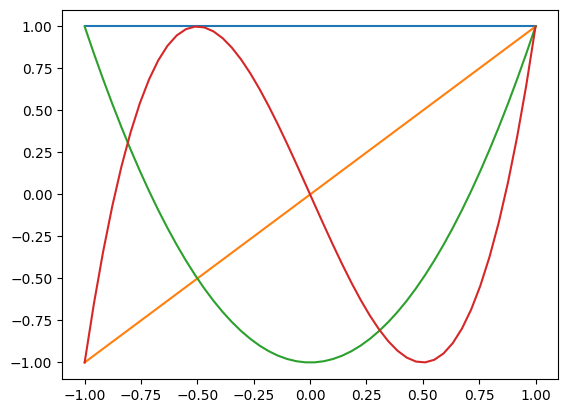

In [2]:
N = 3

chebyshev_basis = [np.polynomial.Chebyshev([0] * i + [1]) for i in range(N + 1)]
plot_basis(chebyshev_basis)

The computation of Chebyshev moments allows us to compute the Gram matrix
$$
E_{jk} = b^\top T_j(A)T_k(A) b.
$$
This, in turn, enables the computation of inner products of polynomials. However, the matrix $E$ is not well conditioned, meaning the computation of inner products is very sensitive to inaccuracies of the moments.

In the limit $d \to \infty$, and under suitable assumptions on $b$, the entries of $E$ are approximated by
$$
E_{jk} \approx \int_{\mathrlap{\lambda_{\min}}}^{\mathrlap{\lambda_{\max}}} \;\; T_j(y)T_k(y) \,\mathrm{d}y.
$$
Let us set $\lambda_{\min} = 0$ and $\lambda_{\max}$ for simplicity.

In [3]:
def inner_positive(P, Q):
    integral = (P * Q).integ()
    return integral(1) - integral(0)


def gram(basis):
    G = np.zeros((len(basis), len(basis)))
    for i, P in enumerate(basis):
        for j, Q in enumerate(basis):
            G[i, j] = inner_positive(P, Q)
    return G

This lets us compute the smallest eigenvalue of $E$. We ensure that the basis is normalized with respect to the sup-norm

In [4]:
def normalize(basis):
    result = []
    for P in basis:
        norm = sup_norm(P)
        if norm > 1:
            P /= norm
        result.append(P)
    return result


def target(basis):
    return np.linalg.eigvalsh(gram(normalize(basis)))[-(N + 1)]


target(chebyshev_basis)

np.float64(0.00011167275022652515)

This value is obviously very small, so one might initially suggest that there is a better basis. Let us try for example some other typical choices.

monomials


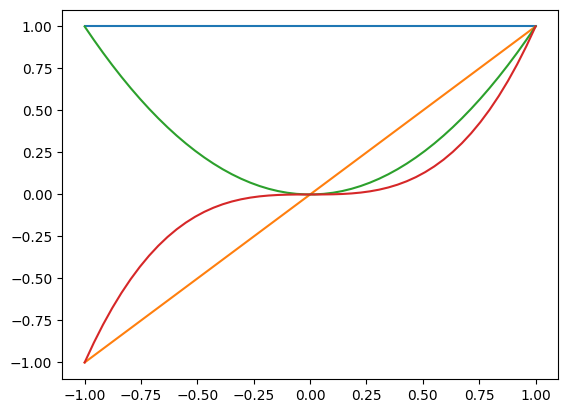

9.670230402260835e-05
chebyshev polynomials of the second kind


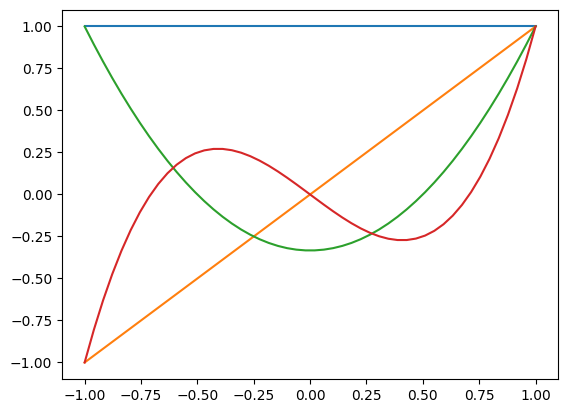

0.00011870118958729886
legendre polynomials


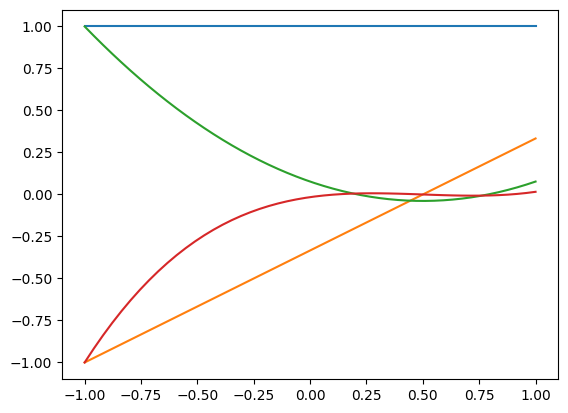

3.599323327214484e-05
lagrange polynomials with chebyshev nodes of the second kind


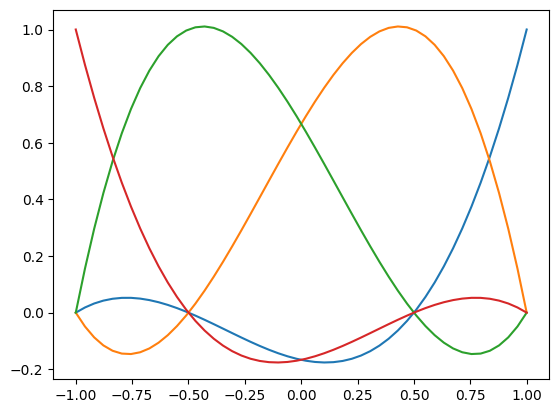

3.239073193091057e-05


In [5]:
print("monomials")
basis = normalize([np.polynomial.Polynomial([0] * i + [1]) for i in range(N + 1)])
plot_basis(basis)
print(target(basis))

print("chebyshev polynomials of the second kind")
basis = normalize(
    [np.polynomial.Chebyshev([0] * i + [0, 1]).deriv() for i in range(N + 1)]
)
plot_basis(basis)
print(target(basis))

print("legendre polynomials")
basis = normalize(
    [np.polynomial.Legendre([0] * i + [1], domain=[0, 1]) for i in range(N + 1)]
)
plot_basis(basis)
print(target(basis))

print("lagrange polynomials with chebyshev nodes of the second kind")
lagrange_basis = []

for i in range(N + 1):
    P = np.polynomial.Chebyshev([1])
    x_i = np.cos(i * np.pi / N)
    for j in range(N + 1):
        if i == j:
            continue
        x_j = np.cos(j * np.pi / N)
        P *= np.polynomial.Chebyshev([-x_j, 1]) / (x_i - x_j)
    lagrange_basis.append(P)
plot_basis(lagrange_basis)
print(target(lagrange_basis))

Out of these, only the Chebyshev polynomials of the second kind perform better. The other choices are worse by a factor of at least $10$. We can also try to find the optimal basis numerically

Try 0: 0.00010683666631220802
Try 1: 0.00011555533802599199
Try 2: 0.00013255417014739198
Try 3: 0.00013944051052546344
Try 4: 0.00011141830118076172
Try 5: 0.00013879680780515329
Try 6: 0.0001393188062563209
Try 7: 7.562825848979294e-05
Try 8: 0.00010603202284503811
Try 9: 0.0001376709157225669
best: 0.00013944051052546344


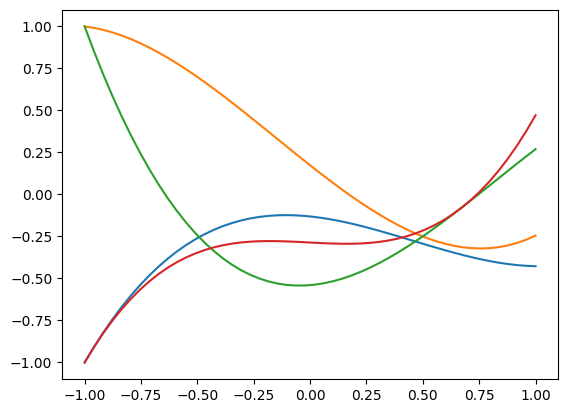

In [6]:
def find_best_basis(max_deg):
    """
    Genetic algorithm to find best basis
    """

    def construct_basis(x):
        x = x.reshape((-1, N + 1))
        basis = []
        for i in range(N + 1):
            P = np.polynomial.Chebyshev(0)
            for j in range(x.shape[1]):
                P += x[j, i] * lagrange_basis[i]
            basis.append(P)
        return basis

    def f(x):
        basis = construct_basis(x)
        return -target(basis)

    steps = 1000
    tries = 10
    # Initalize with Chebyshev polynomials of the second kind
    winner = normalize(
        [np.polynomial.Chebyshev([0] * i + [0, 1]).deriv() for i in range(max_deg + 1)]
    )
    for i in range(tries):
        learning_rate = 0.1
        # For each try, start with a random guess
        basis = normalize(construct_basis(np.random.randn(N + 1, max_deg + 1)))
        result = target(basis)
        for _ in range(steps):
            basis_new = []
            # Randomly modify basis
            for P in basis:
                coef = np.zeros(max_deg + 1)
                coef[: P.degree() + 1] = P.coef
                basis_new.append(
                    np.polynomial.Chebyshev(
                        coef + learning_rate * np.random.randn(max_deg + 1)
                    )
                )
            basis_new = normalize(basis_new)
            result_new = target(basis_new)
            # Keep random modification if basis is better
            if result_new > result:
                basis = basis_new
                result = result_new
                # print(learning_rate)
            learning_rate *= 0.99
        print(f"Try {i}: {result}")
        if result > target(winner):
            winner = basis
    return winner


winner = find_best_basis(N)
print(f"best: {target(winner)}")
plot_basis(winner)

This new basis is slightly better, but only by a factor of $3$. To get better properties, we have to keep the number of polynomials the same, but increase the maximum degree.

Try 0: 0.10618886953681521
Try 1: 0.12132189682646916
Try 2: 0.09865347274111577
Try 3: 0.15243044047928006
Try 4: 0.10131314214951138
Try 5: 0.09611219965772974
Try 6: 0.11179334646307049
Try 7: 0.08546569626465772
Try 8: 0.10532656310922286
Try 9: 0.1111084407594699
best: 0.15243044047928006


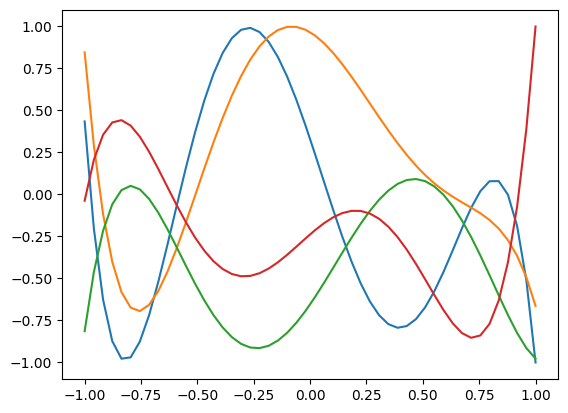

In [7]:
winner = find_best_basis(N + 2)
print(f"best: {target(winner)}")
plot_basis(winner)

But this is now no longer the basis of any polynomial space. This is problematic, since there is not indication whether the optimal polynomial of any degree is even in the span of this generating system.